# 🧪 Step 1: Import Required Libraries


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the original training dataset
df_train = pd.read_csv("data/expense_data_2.csv")  # Update path if needed

# Handle missing values
numeric_cols = df_train.select_dtypes(include=['number']).columns
categorical_cols = df_train.select_dtypes(include=['object']).columns
df_train[numeric_cols] = df_train[numeric_cols].fillna(df_train[numeric_cols].median())
df_train[categorical_cols] = df_train[categorical_cols].fillna(df_train[categorical_cols].mode().iloc[0])

# Convert categorical features
from sklearn.preprocessing import LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])

# Define training features and target
X_train_exp = df_train.drop(columns=["Disposable_Income"])
y_train_exp = df_train[["Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport",
                        "Eating_Out", "Entertainment", "Utilities", "Healthcare",
                        "Education", "Miscellaneous"]]

# Split data again to match original training setup
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_train_exp, y_train_exp, test_size=0.2, random_state=42
)

print("✅ Training data successfully loaded in the testing notebook!")


✅ Training data successfully loaded in the testing notebook!


# 🧪 Step 2: Load the student_spending.csv dataset

In [23]:
df_student = pd.read_csv("data/student_spending.csv")
df_student = df_student.drop(columns=["Unnamed: 0"], errors='ignore')


display(df_student.head())
print("\nColumns:", df_student.columns.tolist())

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card



Columns: ['age', 'gender', 'year_in_school', 'major', 'monthly_income', 'financial_aid', 'tuition', 'housing', 'food', 'transportation', 'books_supplies', 'entertainment', 'personal_care', 'technology', 'health_wellness', 'miscellaneous', 'preferred_payment_method']


# 🧪 Step 3: Rename columns to match the model's expected inputs


In [24]:
column_map = {
    'age': 'Age',
    'monthly_income': 'Income',
    'housing': 'Rent',
    'transportation': 'Transport',
    'food': 'Groceries',
    'entertainment': 'Entertainment',
    'miscellaneous': 'Miscellaneous',
    'books_supplies': 'Education',
    'health_wellness': 'Healthcare',
    'personal_care': 'Utilities'
}

df_student = df_student.rename(columns=column_map)


# 🧪 Step 4: Add and fill missing columns required by the model


In [25]:
expected_cols = [
    'Income', 'Age', 'Dependents', 'Occupation', 'City_Tier',
    'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education',
    'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings'
]

for col in expected_cols:
    if col not in df_student.columns:
        if col in ['Dependents']:
            df_student[col] = 0
        elif col in ['Occupation']:
            df_student[col] = 'Student'
        elif col in ['City_Tier']:
            df_student[col] = 'Tier_3'
        elif col in ['Loan_Repayment', 'Insurance', 'Eating_Out']:
            df_student[col] = 0
        elif col in ['Desired_Savings_Percentage']:
            df_student[col] = 0.2
        elif col in ['Desired_Savings']:
            df_student[col] = df_student['Income'] * df_student['Desired_Savings_Percentage']
        else:
            df_student[col] = 0


# 🧪 Step 5: Encode categorical features


In [26]:
categorical_cols = ['Occupation', 'City_Tier']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_student[col] = le.fit_transform(df_student[col])
    label_encoders[col] = le

# 🧪 Step 6: Select feature columns in correct order for model


In [27]:
X_test_student = df_student[expected_cols]
# 🛠️ Ensure all required columns exist
missing_columns = [
    'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
    'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare',
    'Potential_Savings_Education', 'Potential_Savings_Miscellaneous'
]

# Fill missing potential savings columns with 0 (or a calculated estimate)
for col in missing_columns:
    X_test_student[col] = 0  # Or use an estimate like (X_test_student['Income'] * 0.1)



C:\Users\Ravindu\AppData\Local\Temp\ipykernel_14988\3304027947.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_student[col] = 0  # Or use an estimate like (X_test_student['Income'] * 0.1)
C:\Users\Ravindu\AppData\Local\Temp\ipykernel_14988\3304027947.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_student[col] = 0  # Or use an estimate like (X_test_student['Income'] * 0.1)
C:\Users\Ravindu\AppData\Local\Temp\ipykernel_14988\3304027947.py:11: SettingWithCopyWarning: 
A value is trying

# 🧪 Step 7: Load the trained model


In [28]:
xgb_model = joblib.load("final_optimized_expense_model.pkl")


# 🧪 Step 8: Make predictions


In [29]:
y_pred_student = xgb_model.predict(X_test_student)


# 🧪 Step 9: Display predictions for first few students


In [30]:
expense_columns = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport",
    "Eating_Out", "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous"
]

print("\n📊 Predictions on student_spending.csv:")
for i, row in enumerate(y_pred_student[:5]):
    print(f"\n🧾 Student {i + 1} Predicted Expenses:")
    for j, col in enumerate(expense_columns):
        print(f"{col}: ${row[j]:.2f}")



📊 Predictions on student_spending.csv:

🧾 Student 1 Predicted Expenses:
Rent: $1708.24
Loan_Repayment: $35.25
Insurance: $289.17
Groceries: $832.61
Transport: $468.28
Eating_Out: $304.56
Entertainment: $278.41
Utilities: $444.36
Healthcare: $311.51
Education: $19.05
Miscellaneous: $188.75

🧾 Student 2 Predicted Expenses:
Rent: $1708.24
Loan_Repayment: $10.52
Insurance: $289.17
Groceries: $832.61
Transport: $468.28
Eating_Out: $304.56
Entertainment: $278.41
Utilities: $444.36
Healthcare: $311.51
Education: $19.05
Miscellaneous: $188.75

🧾 Student 3 Predicted Expenses:
Rent: $1708.24
Loan_Repayment: $35.25
Insurance: $289.17
Groceries: $832.61
Transport: $468.28
Eating_Out: $304.56
Entertainment: $278.41
Utilities: $444.36
Healthcare: $311.51
Education: $19.05
Miscellaneous: $195.49

🧾 Student 4 Predicted Expenses:
Rent: $1708.24
Loan_Repayment: $35.25
Insurance: $289.17
Groceries: $832.61
Transport: $468.28
Eating_Out: $304.56
Entertainment: $278.41
Utilities: $444.36
Healthcare: $311.

📌 Step 1: Evaluate Predictions (R², MAE, MSE)


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract actual expenses from student dataset
y_actual_student = df_student[expense_columns]  # Ensure the column names match

# Evaluate predictions
mae_student = mean_absolute_error(y_actual_student, y_pred_student, multioutput='raw_values')
mse_student = mean_squared_error(y_actual_student, y_pred_student, multioutput='raw_values')
r2_student = r2_score(y_actual_student, y_pred_student, multioutput='raw_values')

# Print evaluation results for each category
print("📊 Model Performance on Student Dataset:")
for i, col in enumerate(expense_columns):
    print(f"{col}: R² = {r2_student[i]:.4f}, MAE = {mae_student[i]:.2f}, MSE = {mse_student[i]:.2f}")


📊 Model Performance on Student Dataset:
Rent: R² = -34.9857, MAE = 1012.24, MSE = 1053895.88
Loan_Repayment: R² = 0.0000, MAE = 21.20, MSE = 599.63
Insurance: R² = 0.0000, MAE = 289.17, MSE = 83620.79
Groceries: R² = -44.5352, MAE = 579.96, MSE = 343912.75
Transport: R² = -62.3043, MAE = 343.64, MSE = 119987.13
Eating_Out: R² = 0.0000, MAE = 304.56, MSE = 92759.86
Entertainment: R² = -26.0208, MAE = 193.59, MSE = 38918.45
Utilities: R² = -281.0160, MAE = 383.66, MSE = 147718.39
Healthcare: R² = -15.8283, MAE = 197.20, MSE = 41344.91
Education: R² = -4.6294, MAE = 155.71, MSE = 29482.13
Miscellaneous: R² = -2.4941, MAE = 88.27, MSE = 9588.83


📌 Step 2: Visualize Predictions vs. Actual Expenses


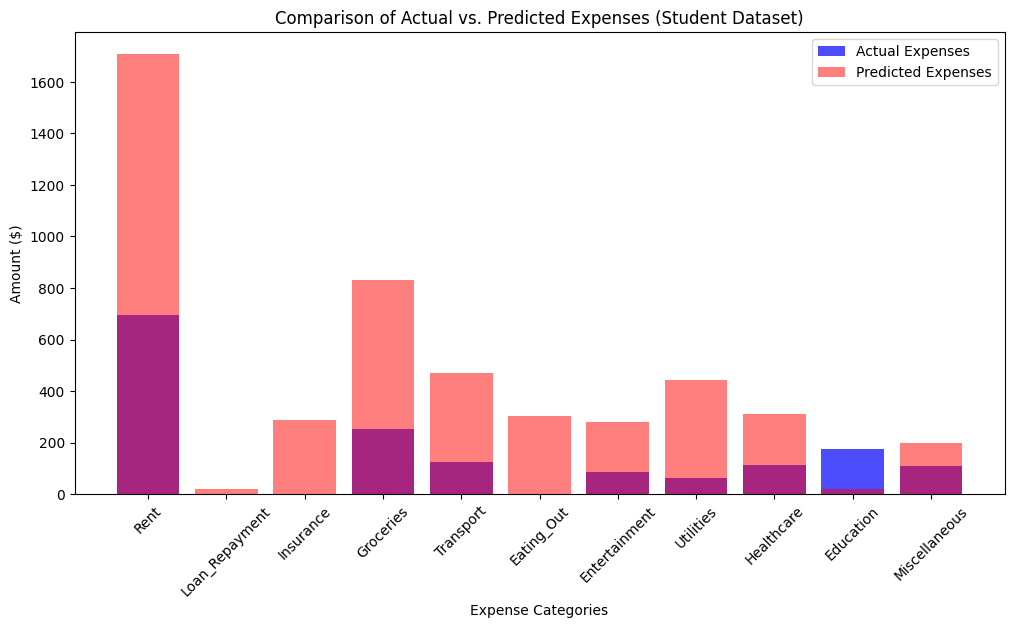

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate mean actual and predicted expenses per category
actual_avg = np.mean(y_actual_student, axis=0)
predicted_avg = np.mean(y_pred_student, axis=0)

# Plot the comparison
plt.figure(figsize=(12, 6))
plt.bar(expense_columns, actual_avg, label="Actual Expenses", color='blue', alpha=0.7)
plt.bar(expense_columns, predicted_avg, label="Predicted Expenses", color='red', alpha=0.5)

# Labels and title
plt.xlabel("Expense Categories")
plt.ylabel("Amount ($)")
plt.title("Comparison of Actual vs. Predicted Expenses (Student Dataset)")
plt.xticks(rotation=45)
plt.legend()
plt.show()


📌 Step 3: Check for Overfitting


In [33]:
# Predict on training data (for comparison)
y_pred_train = xgb_model.predict(X_train_exp)

# Calculate training metrics
r2_train = r2_score(y_train_exp, y_pred_train, multioutput='raw_values')
mae_train = mean_absolute_error(y_train_exp, y_pred_train, multioutput='raw_values')

# Compare Train vs. Student Test Performance
print("📊 Train vs. Student Test Comparison for XGBoost:")
for i, col in enumerate(expense_columns):
    print(f"{col}: Train R² = {r2_train[i]:.4f}, Student Test R² = {r2_student[i]:.4f}")
    print(f"      Train MAE = {mae_train[i]:.2f}, Student Test MAE = {mae_student[i]:.2f}\n")


📊 Train vs. Student Test Comparison for XGBoost:
Rent: Train R² = 0.9900, Student Test R² = -34.9857
      Train MAE = 294.49, Student Test MAE = 1012.24

Loan_Repayment: Train R² = 0.9783, Student Test R² = 0.0000
      Train MAE = 217.31, Student Test MAE = 21.20

Insurance: Train R² = 0.9767, Student Test R² = 0.0000
      Train MAE = 95.54, Student Test MAE = 289.17

Groceries: Train R² = 0.9858, Student Test R² = -44.5352
      Train MAE = 219.95, Student Test MAE = 579.96

Transport: Train R² = 0.9831, Student Test R² = -62.3043
      Train MAE = 121.67, Student Test MAE = 343.64

Eating_Out: Train R² = 0.9774, Student Test R² = 0.0000
      Train MAE = 103.20, Student Test MAE = 304.56

Entertainment: Train R² = 0.9808, Student Test R² = -26.0208
      Train MAE = 83.19, Student Test MAE = 193.59

Utilities: Train R² = 0.9787, Student Test R² = -281.0160
      Train MAE = 121.52, Student Test MAE = 383.66

Healthcare: Train R² = 0.9867, Student Test R² = -15.8283
      Train MAE